<a href="https://colab.research.google.com/github/mariadelmarhernandezh-ai/integracion2026/blob/main/Reto_2_Integracion_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Taller Integracion de datos - Teoria de la credibilidad**

En este espacio de trabajo se plantea como caso de estudio el proceso de integración de datos en una entidad FINTECH cuyo modelo de negocio se soporta principalmente en canales electrónicos para la prestación de servicios financieros. Debido a la alta dependencia tecnológica, la organización se encuentra expuesta a eventos de riesgo operativo asociados a fallos en transacciones digitales, los cuales generan pérdidas económicas reportadas en diferentes períodos de tiempo. Para analizar este fenómeno, el riesgo se describe a partir de dos variables aleatorias: la frecuencia, que representa el número de fallos tecnológicos registrados en un período determinado, y la severidad, que corresponde al valor promedio de las pérdidas ocasionadas por cada evento. A partir de la combinación de estas variables se construye la distribución agregada de pérdidas bajo el enfoque LDA (Loss Distribution Approach), la cual será caracterizada mediante medidas de tendencia central y dispersión. Adicionalmente, el caso contempla la integración de una base de datos interna con una base externa mediante la aplicación de la teoría de la credibilidad, permitiendo evaluar la afinidad entre fuentes y mejorar la calidad de la estimación. Para esto se utilizará el método de Monte Carlo, con el fin de simular escenarios y fortalecer el proceso analítico dentro del ejercicio de integración de datos.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns #esta libreria es para el trabajo estadistico
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive') #descargar la carpeta de riesgo operacional

Mounted at /content/drive


In [3]:
nxl='/content/drive/MyDrive/Integracion de datos y prospectiva/1. FallasTecnológicas.xlsx'
XDB=pd.read_excel(nxl,sheet_name=0)
XDB.head(10) #esto es para saber cuantas lineas del data frame muestra

#procedemos con la construccion de la distribucion agregada de las perdidas
Freq=pd.to_numeric(XDB.iloc[:,3], errors='coerce').dropna() #Transacciones fallidas por dia
Sev=pd.to_numeric(XDB.iloc[:,4], errors='coerce').dropna() #perdida asociada a cada fallo
LDA=Freq*Sev

#se procede a cargar la base de datos externa (DATOS EXTERNOS- Admon Ejec Procesos)

nxle='/content/drive/MyDrive/Integracion de datos y prospectiva/2. AdmonEjecProcesos.xlsx'
XDBe=pd.read_excel(nxle,sheet_name=0)
XDBe.head(10)

#2. procedemos con la construccion de la distribucion agregada de las perdidas
Freqe=pd.to_numeric(XDBe.iloc[:,3], errors='coerce').dropna() #transacciones fallidas
Seve=pd.to_numeric(XDBe.iloc[:,4], errors='coerce').dropna() #valor generado
LDAe=Freqe*Seve

Se crea el metodo para la caracterizacion de variables aleatorias (Frecuencia, Severidad, Distribucion de las perdidas)

In [4]:
def caracterizacion (LDA):
  #se porcede con la creacion de la distribucion
   plt.figure(figsize=(10,5))
   sns.histplot(LDA,bins=10,kde=True)
   plt.xlabel("perdida (KUSD)")
   plt.grid()
   plt.show()

   #Se procede con la caracterizacion de cada una de las variables
   np.set_printoptions(suppress=True)
   NI=10 #indica el numero de clusters
   counts,bin_edges=np.histogram(LDA,bins=NI)
   print("El numero de datos por intervalo es : ")
   print(counts)
   print("Los intervalos inferiores: ")
   print(bin_edges[:-1])
   print("Los intervalos superiores: ")
   print(bin_edges[1:])
   XC=(bin_edges[:-1]+bin_edges[1:])/2

   #Se configura la tabla de datos
   Tabla=np.column_stack((bin_edges[:-1],bin_edges[1:],XC,counts))
   df=pd.DataFrame(Tabla,columns=['LI','LS','XC','ND'])
   df.head(10)

   #Se procede con la estimacion de la media
   fr=counts/np.sum(counts)
   u=np.sum(XC*fr)
   sigma2=np.sum(fr*(XC-u)**2)
   sigma=np.sqrt(sigma2)
   sigma=np.sqrt(sigma2)
   Cas=np.sum(fr*(XC-u)**3)/sigma**3
   Kur=(np.sum(fr*(XC-u)**4)/sigma**4)-3
   return u,sigma,Cas,Kur,df

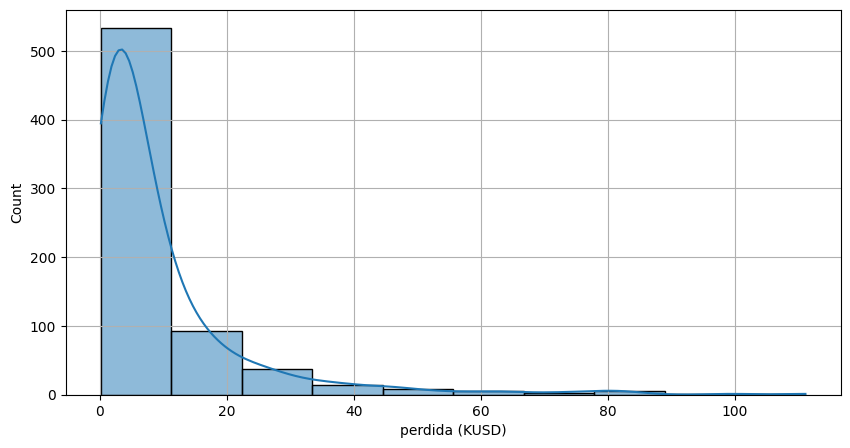

El numero de datos por intervalo es : 
[533  93  37  14   9   5   3   5   1   1]
Los intervalos inferiores: 
[ 0.1423  11.23637 22.33044 33.42451 44.51858 55.61265 66.70672 77.80079
 88.89486 99.98893]
Los intervalos superiores: 
[ 11.23637  22.33044  33.42451  44.51858  55.61265  66.70672  77.80079
  88.89486  99.98893 111.083  ]
La media de los datos observados es:  11.07019634094151
El coeficiente de Asimetria es:  3.5824155186772604


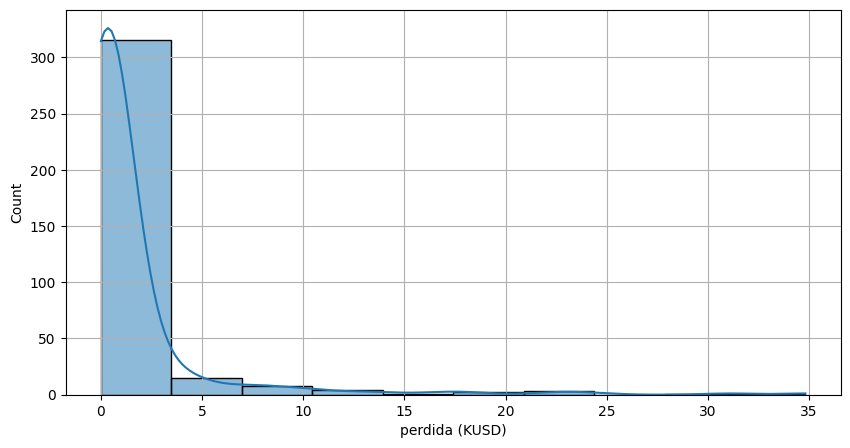

El numero de datos por intervalo es : 
[315  15   8   4   1   2   3   0   1   1]
Los intervalos inferiores: 
[ 0.          3.48221562  6.96443124 10.44664686 13.92886248 17.4110781
 20.89329372 24.37550933 27.85772495 31.33994057]
Los intervalos superiores: 
[ 3.48221562  6.96443124 10.44664686 13.92886248 17.4110781  20.89329372
 24.37550933 27.85772495 31.33994057 34.82215619]
La media de los datos externos es:  2.656433058055811
El coeficiente de Asimetria es:  5.313307467317224
La credibilidad de la base de datos externa es:  0.01057829191054338
Se conoce como la fracuencia de las perdidas: 2.745436302128388


In [5]:
#3. Comparacion estadistica (Media, Varianza, Desviacion, Asmietria. Kurtosis)

#3.1 Base de datos observados (Fallas tecnologicas)
uo,sigmao,Caso,Kuo,dfo=caracterizacion(LDA)
print("La media de los datos observados es: ",uo)
print("El coeficiente de Asimetria es: ",Caso)

#3.2 Base de datos externas (Admon ejec procesos)
ue,sigmae,Case,Kue,dfe=caracterizacion(LDAe)
print("La media de los datos externos es: ",ue)
print("El coeficiente de Asimetria es: ",Case)

#4. Teoria de credibilidad
#4.1 Media hipotetica

NDo=len(LDA); NDe=len(LDAe) #para saber la inercia de los datos
uhat=(NDo*uo+NDe*ue)/(NDo+NDe)

#4.2 EPV= Valor Esperado de la Varianza
EPV=(NDo*sigmao**2+NDe*sigmae**2)/(NDo+NDe) #Determinar la varianza conjunta de los datos

#4.3 VHM Varianza Hipotetica de la Media
VHM=((NDo*uo**2+NDe*ue**2)/(NDo+NDe))-uhat**2

#4.4 Factor de credibilidad
fc=EPV/VHM

#4.5 Credibilidad de la base de datos
Cr=1-(NDo/(NDo+fc))
print("La credibilidad de la base de datos externa es: ",Cr) #Siempre que este por encima del 75% puedo integrar las bases de datos

#5. Parametros de Riesgo

#5.1 Perdidas asumibles (Media: Franquicia): Media hipotetica de los datos integrados
PEs=Cr*uo+(1-Cr)*ue
print("Se conoce como la fracuencia de las perdidas:", PEs)

A partir del análisis estadístico realizado, puedo observar que la media de las pérdidas entre la base interna (uo=11.07) y externa (ue=2.256) presenta una diferencia considerable, esto indica que hay comportamientos operativos distintos entre ambas bases de datos. En cuanto al coeficiente de asimetria, ambas bases muestran asimetría positiva (Caso=3.582 , Case=5.313),esto refleja que hay pérdidas pequeñas y presencia de eventos extremos pero la base externa muestra mayor grado de asimetría, esto indica una concentración mayor en valores bajos. Como resultado de estas diferencias en tendencia central y dispersión, el coeficiente de credibilidad que se obtuvo es muy bajo, esto demuestra que hay baja relacion estadística entre las bases de datos, es decir, que esta base externa no va a ser muy util a la hora de hacer nuestro analisis

**Metodo de Montecarlo**, es un metodo que utiliza una ruleta cargada, dependiendo de las probabilidades que genera el histograma

Calcular las metricas estadisticas de tendencia central y dispersion (Media, Desviacion, Asimetria y Kurtosis)

In [6]:
u=np.mean(LDA)
var=np.var(LDA)
sigma=np.std (LDA) #corrected calculator standard deviation

T2=np.column_stack((u,var,sigma))
df2=pd.DataFrame(T2,columns=['Media','Varianza', 'Desviacion'])
df2.head(1)


from scipy.stats import skew, kurtosis
#Calculate skewness
lda_skew=skew(LDA)

#Calculate kurtosis
lda_kurtosis=kurtosis(LDA)

# add to the DataFrame with other metrics
df2_temp=df2.copy()
df2_temp['Asimetria']= lda_skew
df2_temp['Kurtosis']= lda_kurtosis

display(df2_temp)

,Media,Varianza,Desviacion,Asimetria,Kurtosis
0,9.451113,187.894776,13.707472,3.34836,14.167714


**Analisis de resultados**

A partir de las métricas de tendencia central y dispersión, pude observar que la distribución de las pérdidas asociadas a fallas tecnológicas presentan un valor promedio moderado y una desviación estándar elevada, lo que indica una alta variabilidad en el impacto económico de los eventos. El coeficiente de asimetría positivo (3.35), superior a la unidad, muestra que la mayoría de las pérdidas se concentran en valores bajos, mientras que existe una cola derecha larga que representa eventos poco frecuentes pero que tienen un impacto economico alto. Es decir que en general, las fallas tecnológicas generan pérdidas menores, aunque ocasionalmente pueden haber eventos significativos dentro del sistema. En cuanto al coeficiente de curtosis (14.17) indica una distribución fuertemente leptocúrtica, que se caracteriza por un pico pronunciado y colas pesadas. Observando todo en conjunto, estos resultados muestran que el comportamiento de las pérdidas en canales electrónicos está dominado por eventos frecuentes de bajo impacto y por eventos ocasionales de fallas críticas que incrementan la exposición al riesgo operativo.

Interpretacion de la asimetria y la kurtosis

In [7]:
#usando los valores calculados previamente
lda_skew= 3.34836
lda_kurtosis=14.167714

print(f"Asimetria (Skewness) de LDA: {lda_skew:.4f}")
print(f"Curtosis (Kurtosis) de LDA: {lda_kurtosis:.4f}")

#interpretacion de la Asimetria
if lda_skew > 0.5:
  print("La distribucion de LDA es fuertemente asimetrica positiva, lo que indica que la cola derecha es más larga, existen valores atípicos grandes y la mayoría de los datos se concentran a la izquierda de la media.")
elif lda_skew < -0.5:
  print("La distribucion de LDA es fuertemente asimetrica negativa, lo que indica que la cola izquierda es más larga, existen valores atípicos pequeños y la mayoría de los datos se concentran a la derecha de la media.")
else:
  print("La distribucion de LDA es aproximadamente simetrica, lo que indica que los datos se distribuyen de forma equilibrada alrededor de la media, similar al comportamiento de una distribución normal.")

#Interpretacion de la Curtosis (usando curtosis en exceso)
if lda_kurtosis > 1:
  print("La distribucion de LDA es leptocurtica,con un pico mas pronunciado y mayor presencia de valores atípicos.")
elif lda_kurtosis < -1:
  print("La distribucion de LDA es platicurtica, con pico plano y menor presencia de valores atípicos.")
else:
  print("La distribucion de LDA es mesocurtica, similar a una distribución normal.")

Asimetria (Skewness) de LDA: 3.3484
Curtosis (Kurtosis) de LDA: 14.1677
La distribucion de LDA es fuertemente asimetrica positiva, lo que indica que la cola derecha es más larga, existen valores atípicos grandes y la mayoría de los datos se concentran a la izquierda de la media.
La distribucion de LDA es leptocurtica,con un pico mas pronunciado y mayor presencia de valores atípicos.


**LDA integrada**

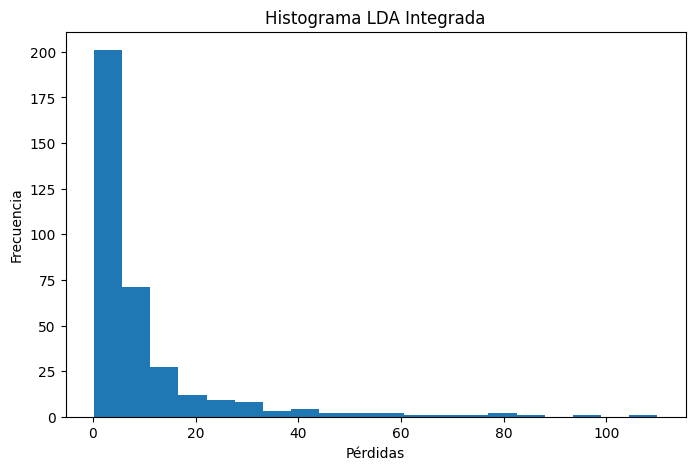

In [10]:
Z = 0.01057829191054338 #credibilidad base de datos externa

LDA_integrada = Z * LDAe + (1 - Z) * LDA

LDA_integrada.head()

#histograma de la distribucion integrada

plt.figure(figsize=(8,5))
plt.hist(LDA_integrada, bins=20)
plt.title("Histograma LDA Integrada")
plt.xlabel("Pérdidas")
plt.ylabel("Frecuencia")
plt.show()



In [11]:
#Caracterizacion estadistica de la LDA integrada

media_int = np.mean(LDA_integrada)
var_int = np.var(LDA_integrada)
std_int = np.std(LDA_integrada)
skew_int = skew(LDA_integrada)
kurt_int = kurtosis(LDA_integrada)

print("Media:", media_int)
print("Varianza:", var_int)
print("Desviación:", std_int)
print("Asimetría:", skew_int)
print("Curtosis:", kurt_int)


Media: 9.528626759620877
Varianza: 226.8549972990535
Desviación: 15.061706320966875
Asimetría: nan
Curtosis: nan
